Step 1:
Clean and prepare your data: There are several entries where values have been deleted to simulate dirty data. Please clean the data with whatever method(s) you believe is best/most suitable. Note that some of the missing values are truly blank (unknown answers) and thus may be impossible to clean; use your discretion.

Step 2:
Build your models: Please build machine learning/statistical models in Python to predict the interest rate assigned to a loan. When writing the code associated with each model, please have the first part produce and save the model, followed by a second part that loads and applies the model.

Step 3:
Test your models using the data found within the "Holdout for Testing" file. Save the results of the final model (remember you will only predict the first column in holdout test set with your best model results) in a single, separate CSV titled "Results from" *insert your name or UChicago net ID.

Step 4:
Submit your work: Please submit all of your code for cleaning, prepping, and modeling your data, your "Results" file, a brief write-up comparing the pros and cons of the modeling techniques you used (no more than a paragraph). Your work will be scored on techniques used (appropriateness and complexity), model performance - measured by RMSE - on the data hold out, an understanding of the techniques you compared in your write-up, and your overall code.


## Step 1 - Data Preprocessing 


In [1]:
# Access libraries 

import numpy as np
import pandas as pd
import scipy as sp
from scipy import stats
import seaborn as sns
# Seaborn color palettes: https://seaborn.pydata.org/tutorial/color_palettes.html 
import matplotlib.pyplot as plt
import sklearn 

from pylab import rcParams
from sklearn import preprocessing
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cross_validation import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
import sklearn.model_selection as cv


ModuleNotFoundError: No module named 'sklearn.cross_validation'

In [ ]:

%matplotlib inline
rcParams['figure.figsize'] = 10, 8
sns.set_style('whitegrid') 

In [5]:


cleaning = pd.read_csv("Data for Cleaning & Modeling.csv")

cleaning.tail()


NameError: name 'pd' is not defined

In [86]:
holdout = pd.read_csv("Holdout for Testing.csv")
holdout.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X23,X24,X25,X26,X27,X28,X29,X30,X31,X32
0,NaN,44409194,47416907,"$6,000","$6,000","$6,000",36 months,C,C5,Electrician,...,11/2/2019,1,26.0,NaN,18,0,19861,64.50%,33,f
1,NaN,44017917,47034722,"$24,000","$24,000","$24,000",36 months,A,A1,Executive Assistant,...,12/1/1968,1,NaN,NaN,12,0,17001,26.20%,36,w
2,NaN,44259158,47306871,"$35,000","$35,000","$35,000",36 months,C,C2,District Sales Leader,...,10/1/1998,0,NaN,NaN,16,0,25797,49.90%,33,w
3,NaN,44429213,47476932,"$10,000","$10,000","$10,000",60 months,D,D1,pharmacy associate,...,2/1/1999,1,NaN,114.0,13,1,9586,43.80%,21,w
4,NaN,44299188,47346901,"$24,000","$24,000","$24,000",60 months,B,B1,Medical case manager,...,12/2/2019,0,48.0,NaN,27,0,31842,41.30%,43,w


In [87]:
with open("Metadata.csv", 'rb') as f:
     lines = [l.decode('utf8', 'ignore') for l in f.readlines()]


In [7]:
lines

['Variable,Definition\rX1,Interest Rate on the loan\rX2,A unique id for the loan.\rX3,A unique id assigned for the borrower.\rX4,Loan amount requested\rX5,Loan amount funded\rX6,Investor-funded portion of loan\rX7,Number of payments (36 or 60)\rX8,Loan grade\rX9,Loan subgrade\rX10,Employer or job title (self-filled)\rX11,Number of years employed (0 to 10; 10 = 10 or more)\rX12,"Home ownership status: RENT, OWN, MORTGAGE, OTHER."\rX13,Annual income of borrower\rX14,"Income verified, not verified, or income source was verified"\rX15,Date loan was issued\rX16,Reason for loan provided by borrower\rX17,"Loan category, as provided by borrower"\rX18,"Loan title, as provided by borrower"\rX19,First 3 numbers of zip code\rX20,State of borrower\rX21,"A ratio calculated using the borrower۪s total monthly debt payments on the total debt obligations, excluding mortgage and the requested loan, divided by the borrower۪s self-reported monthly income."\rX22,The number of 30+ days past-due incidences of

In [8]:
cleaning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 32 columns):
X1     338990 non-null object
X2     399999 non-null float64
X3     399999 non-null float64
X4     399999 non-null object
X5     399999 non-null object
X6     399999 non-null object
X7     399999 non-null object
X8     338730 non-null object
X9     338730 non-null object
X10    376018 non-null object
X11    399999 non-null object
X12    338639 non-null object
X13    338972 non-null float64
X14    399999 non-null object
X15    399999 non-null object
X16    123561 non-null object
X17    399999 non-null object
X18    399982 non-null object
X19    399999 non-null object
X20    399999 non-null object
X21    399999 non-null float64
X22    399999 non-null float64
X23    399999 non-null object
X24    399999 non-null float64
X25    181198 non-null float64
X26    51155 non-null float64
X27    399999 non-null float64
X28    399999 non-null float64
X29    399999 non-null float64
X30    39

In [226]:
total = cleaning.isnull().sum().sort_values(ascending=False)
percent_1 = cleaning.isnull().sum() / cleaning.isnull().count()*100
percent_2 = (round(percent_1, 1)).sort_values(ascending=False)
missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])

In [227]:
missing_data

,Total,%
X1,61010,15.3
X10,23982,6.0
X11,1,0.0
X12,61361,15.3
X13,61028,15.3
X14,1,0.0
X15,1,0.0
X16,276439,69.1
X17,1,0.0
X18,18,0.0


In [228]:
cleaning2 = cleaning.drop(['X16', 'X25', 'X26'], 1)

holdout2 = holdout.drop(['X16', 'X25', 'X26'], 1) 

In [91]:
cleaning2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 29 columns):
X1     338990 non-null object
X2     399999 non-null float64
X3     399999 non-null float64
X4     399999 non-null object
X5     399999 non-null object
X6     399999 non-null object
X7     399999 non-null object
X8     338730 non-null object
X9     338730 non-null object
X10    376018 non-null object
X11    399999 non-null object
X12    338639 non-null object
X13    338972 non-null float64
X14    399999 non-null object
X15    399999 non-null object
X17    399999 non-null object
X18    399982 non-null object
X19    399999 non-null object
X20    399999 non-null object
X21    399999 non-null float64
X22    399999 non-null float64
X23    399999 non-null object
X24    399999 non-null float64
X27    399999 non-null float64
X28    399999 non-null float64
X29    399999 non-null float64
X30    399733 non-null object
X31    399999 non-null float64
X32    399999 non-null object
dtypes: f

In [92]:
cleaning2.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X21,X22,X23,X24,X27,X28,X29,X30,X31,X32
0,11.89%,54734.0,80364.0,"$25,000","$25,000","$19,080",36 months,B,B4,NaN,...,19.48,0.0,2/1/1994,0.0,10.0,0.0,28854.0,52.10%,42.0,f
1,10.71%,55742.0,114426.0,"$7,000","$7,000",$673,36 months,B,B5,CNN,...,14.29,0.0,10/1/2000,0.0,7.0,0.0,33623.0,76.70%,7.0,f
2,16.99%,57167.0,137225.0,"$25,000","$25,000","$24,725",36 months,D,D3,Web Programmer,...,10.50,0.0,6/1/2000,0.0,10.0,0.0,19878.0,66.30%,17.0,f
3,13.11%,57245.0,138150.0,"$1,200","$1,200","$1,200",36 months,C,C2,city of beaumont texas,...,5.47,0.0,1/1/1985,0.0,5.0,0.0,2584.0,40.40%,31.0,f
4,13.57%,57416.0,139635.0,"$10,800","$10,800","$10,692",36 months,C,C3,State Farm Insurance,...,11.63,0.0,12/1/1996,1.0,14.0,0.0,3511.0,25.60%,40.0,f


In [229]:
cols = ['X1', 'X30']

cleaning2[cols] = cleaning2[cols].replace({'\%': ''}, regex = True)

holdout2[cols] = holdout2[cols].replace({'\%': ''}, regex = True)

In [230]:
cols = ['X4', 'X5', 'X6']

cleaning2[cols] = cleaning2[cols].replace({'\$': '', ',': ''}, regex = True)

holdout2[cols] = holdout2[cols].replace({'\$': '', ',': ''}, regex = True)

In [231]:
cleaning2

holdout2

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X21,X22,X23,X24,X27,X28,X29,X30,X31,X32
0,NaN,44409194,47416907,6000,6000,6000,36 months,C,C5,Electrician,...,28.31,0,11/2/2019,1,18,0,19861,64.50,33,f
1,NaN,44017917,47034722,24000,24000,24000,36 months,A,A1,Executive Assistant,...,16.03,0,12/1/1968,1,12,0,17001,26.20,36,w
2,NaN,44259158,47306871,35000,35000,35000,36 months,C,C2,District Sales Leader,...,32.49,0,10/1/1998,0,16,0,25797,49.90,33,w
3,NaN,44429213,47476932,10000,10000,10000,60 months,D,D1,pharmacy associate,...,32.96,0,2/1/1999,1,13,1,9586,43.80,21,w
4,NaN,44299188,47346901,24000,24000,24000,60 months,B,B1,Medical case manager,...,31.03,0,12/2/2019,0,27,0,31842,41.30,43,w
5,NaN,44057008,47073801,18000,18000,18000,60 months,B,B3,Solutions Development Senior Analyst,...,34.33,0,8/1/1998,0,8,0,18652,64.80,21,w
6,NaN,41399898,44316683,8000,8000,8000,36 months,C,C3,Department Manager,...,14.20,0,6/6/2019,0,7,0,13775,63.20,10,w
7,NaN,43801789,46818598,24000,24000,24000,36 months,B,B2,Senior pastor,...,16.32,0,8/1/2019,1,10,0,20417,68.70,19,w
8,NaN,44409120,47416833,18000,18000,18000,60 months,C,C4,Regulatory Compliance,...,17.72,0,1/2/2019,0,9,0,3948,66.90,23,w
9,NaN,44319155,47376870,25000,25000,25000,36 months,A,A2,Strategist,...,10.98,1,12/1/2000,0,12,0,12689,41.30,25,w


In [232]:
cleaning2.X7 = cleaning2.X7.str.replace('months', '')

holdout2.X7 = holdout2.X7.str.replace('months', '')

In [233]:
cols = ['X1','X4','X5','X6','X7','X30']

cleaning2[cols] = cleaning2[cols].apply(pd.to_numeric, errors='coerce', axis=1)

holdout2[cols] = holdout2[cols].apply(pd.to_numeric, errors='coerce', axis=1)

In [234]:
cleaning2[['X1', 'X30']] = cleaning2[['X1', 'X30']] / 100
holdout2[['X1', 'X30']] = holdout2[['X1', 'X30']] / 100

In [235]:
holdout2.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X21,X22,X23,X24,X27,X28,X29,X30,X31,X32
0,NaN,44409194,47416907,6000.0,6000.0,6000.0,36.0,C,C5,Electrician,...,28.31,0,11/2/2019,1,18,0,19861,0.645,33,f
1,NaN,44017917,47034722,24000.0,24000.0,24000.0,36.0,A,A1,Executive Assistant,...,16.03,0,12/1/1968,1,12,0,17001,0.262,36,w
2,NaN,44259158,47306871,35000.0,35000.0,35000.0,36.0,C,C2,District Sales Leader,...,32.49,0,10/1/1998,0,16,0,25797,0.499,33,w
3,NaN,44429213,47476932,10000.0,10000.0,10000.0,60.0,D,D1,pharmacy associate,...,32.96,0,2/1/1999,1,13,1,9586,0.438,21,w
4,NaN,44299188,47346901,24000.0,24000.0,24000.0,60.0,B,B1,Medical case manager,...,31.03,0,12/2/2019,0,27,0,31842,0.413,43,w


In [100]:
cleaning2[['X1', 'X30']].head()

,X1,X30
0,0.1189,0.521
1,0.1071,0.767
2,0.1699,0.663
3,0.1311,0.404
4,0.1357,0.256


In [101]:
cleaning2.iloc[: ,0:10].head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,0.1189,54734.0,80364.0,25000.0,25000.0,19080.0,36.0,B,B4,NaN
1,0.1071,55742.0,114426.0,7000.0,7000.0,673.0,36.0,B,B5,CNN
2,0.1699,57167.0,137225.0,25000.0,25000.0,24725.0,36.0,D,D3,Web Programmer
3,0.1311,57245.0,138150.0,1200.0,1200.0,1200.0,36.0,C,C2,city of beaumont texas
4,0.1357,57416.0,139635.0,10800.0,10800.0,10692.0,36.0,C,C3,State Farm Insurance


In [236]:
cleaning2.X8 = pd.Categorical(cleaning2.X8) 
cleaning2['X8'] = cleaning2.X8.cat.codes

holdout2.X8 = pd.Categorical(holdout2.X8) 
holdout2['X8'] = holdout2.X8.cat.codes

In [237]:
cleaning2.iloc[:, 10:20].head()

,X11,X12,X13,X14,X15,X17,X18,X19,X20,X21
0,< 1 year,rent,85000.0,verified - income,8/9/2019,debt_consolidation,Debt consolidation for on-time payer,941xx,CA,19.48
1,< 1 year,rent,65000.0,not verified,5/8/2019,credit_card,Credit Card payoff,112xx,NY,14.29
2,1 year,rent,70000.0,verified - income,8/14/2019,debt_consolidation,mlue,100xx,NY,10.50
3,10+ years,own,54000.0,not verified,3/10/2019,debt_consolidation,zxcvb,777xx,TX,5.47
4,6 years,rent,32000.0,not verified,11/9/2019,debt_consolidation,Nicolechr1978,067xx,CT,11.63


In [238]:
cleaning2.iloc[:, 20:33].tail()

,X22,X23,X24,X27,X28,X29,X30,X31,X32
399995,0.0,11/3/2019,0.0,9.0,0.0,10268.0,0.761,20.0,w
399996,0.0,10/7/2019,0.0,11.0,0.0,8931.0,0.378,21.0,f
399997,0.0,10/4/2019,0.0,14.0,0.0,28976.0,0.693,48.0,w
399998,0.0,3/1/1994,0.0,19.0,0.0,11982.0,0.390,31.0,f
399999,0.0,9/10/2019,0.0,9.0,0.0,3864.0,0.537,12.0,f


In [239]:
cleaning2.X24.unique()

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   8.,   7.,  nan])

In [240]:
holdout2.iloc[:, 20:30].head()

,X22,X23,X24,X27,X28,X29,X30,X31,X32
0,0,11/2/2019,1,18,0,19861,0.645,33,f
1,0,12/1/1968,1,12,0,17001,0.262,36,w
2,0,10/1/1998,0,16,0,25797,0.499,33,w
3,0,2/1/1999,1,13,1,9586,0.438,21,w
4,0,12/2/2019,0,27,0,31842,0.413,43,w


In [241]:
cleaning2 = cleaning2.drop(['X22', 'X24'], 1)

holdout2 = holdout2.drop(['X22', 'X24'], 1)

In [242]:
cleaning['X12'] = cleaning['X12'].str.lower()

holdout2['X12'] = holdout2['X12'].str.lower()

In [243]:
cleaning['X14'] = cleaning['X14'].str.lower()

holdout2['X14'] = holdout2['X14'].str.lower()

In [110]:
cleaning2.iloc[:, 15:25].tail()

,X17,X18,X19,X20,X21,X23,X27,X28,X29,X30
399995,credit_card,Credit card refinancing,331xx,FL,21.51,11/3/2019,9.0,0.0,10268.0,0.761
399996,debt_consolidation,Debt consolidation,770xx,TX,29.76,10/7/2019,11.0,0.0,8931.0,0.378
399997,credit_card,Credit card refinancing,750xx,TX,24.13,10/4/2019,14.0,0.0,28976.0,0.693
399998,debt_consolidation,Debt consolidation,783xx,TX,31.43,3/1/1994,19.0,0.0,11982.0,0.390
399999,debt_consolidation,Debt consolidation,774xx,TX,16.48,9/10/2019,9.0,0.0,3864.0,0.537


In [244]:
cleaning2.X19 = cleaning2.X19.str.replace('xx', '')

holdout2.X19 = holdout2.X19.str.replace('xx', '')

In [112]:
cleaning3 = cleaning2.dropna(axis=0)

In [113]:
cleaning3.isnull().sum()

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X17    0
X18    0
X19    0
X20    0
X21    0
X23    0
X27    0
X28    0
X29    0
X30    0
X31    0
X32    0
dtype: int64

In [4]:
cleaning3['X19'] = cleaning3['X19'].astype(str).astype(int)

NameError: name 'cleaning3' is not defined

In [246]:
cleaning3.X8 = pd.Categorical(cleaning3.X8)  
cleaning3.X9 = pd.Categorical(cleaning3.X9)  


In [116]:
cleaning3.iloc[: ,20:30].head()

,X23,X27,X28,X29,X30,X31,X32
1,10/1/2000,7.0,0.0,33623.0,0.767,7.0,f
2,6/1/2000,10.0,0.0,19878.0,0.663,17.0,f
3,1/1/1985,5.0,0.0,2584.0,0.404,31.0,f
4,12/1/1996,14.0,0.0,3511.0,0.256,40.0,f
5,4/1/1994,6.0,0.0,3874.0,0.901,25.0,f


In [2]:
cleaning3.X32 = pd.Categorical(cleaning3.X32) 
cleaning3['X32'] = cleaning3.X32.cat.codes

holdout2.X32 = pd.Categorical(holdout2.X32) 
holdout2['X32'] = holdout2.X32.cat.codes

NameError: name 'pd' is not defined

In [3]:
cleaning3.X9 = pd.Categorical(cleaning3.X9) 
cleaning3['X9'] = cleaning3.X9.cat.codes

holdout2.X9 = pd.Categorical(holdout2.X9) 
holdout2['X9'] = holdout2.X9.cat.codes

NameError: name 'pd' is not defined

In [119]:
cleaning3 = cleaning3.drop(['X9'], 1)

holdout2 = holdout2.drop(['X9'], 1)

In [254]:
holdout2 = holdout2.fillna(0)

In [120]:
cleaning3.iloc[: ,20:30].head()

,X27,X28,X29,X30,X31,X32
1,7.0,0.0,33623.0,0.767,7.0,0
2,10.0,0.0,19878.0,0.663,17.0,0
3,5.0,0.0,2584.0,0.404,31.0,0
4,14.0,0.0,3511.0,0.256,40.0,0
5,6.0,0.0,3874.0,0.901,25.0,0


## Visualize Data 

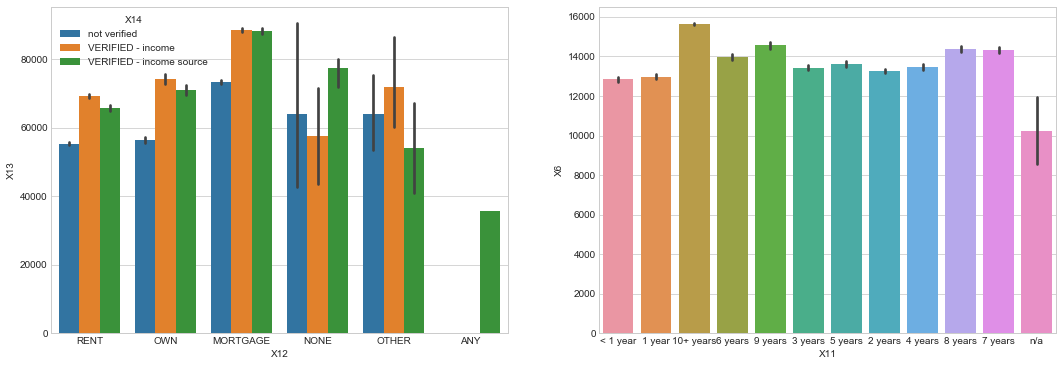

In [69]:
fig, (axis1,axis2) = plt.subplots(1,2,figsize=(18,6))
sns.barplot(x="X12", y="X13", hue="X14", data=cleaning3, ax = axis1);
sns.barplot(x="X11", y="X6", data=cleaning3, ax = axis2);

In [126]:
cleaning3.isnull().sum()

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X17    0
X18    0
X19    0
X20    0
X21    0
X23    0
X27    0
X28    0
X29    0
X30    0
X31    0
X32    0
dtype: int64

In [127]:
cleaning4 = cleaning3.drop(['X10', 'X11', 'X12', 'X14', 'X15', 'X17', 'X18', 'X20', 'X23'], 1)

In [128]:
cleaning4.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X13,X19,X21,X27,X28,X29,X30,X31,X32
1,0.1071,55742.0,114426.0,7000.0,7000.0,673.0,36.0,1,65000.0,112,14.29,7.0,0.0,33623.0,0.767,7.0,0
2,0.1699,57167.0,137225.0,25000.0,25000.0,24725.0,36.0,3,70000.0,100,10.50,10.0,0.0,19878.0,0.663,17.0,0
3,0.1311,57245.0,138150.0,1200.0,1200.0,1200.0,36.0,2,54000.0,777,5.47,5.0,0.0,2584.0,0.404,31.0,0
4,0.1357,57416.0,139635.0,10800.0,10800.0,10692.0,36.0,2,32000.0,67,11.63,14.0,0.0,3511.0,0.256,40.0,0
5,0.1905,58524.0,149512.0,7200.0,7200.0,7200.0,36.0,3,58000.0,28,2.05,6.0,0.0,3874.0,0.901,25.0,0


In [129]:
cleaning4.isnull().any()

X1     False
X2     False
X3     False
X4     False
X5     False
X6     False
X7     False
X8     False
X13    False
X19    False
X21    False
X27    False
X28    False
X29    False
X30    False
X31    False
X32    False
dtype: bool

In [130]:
target = cleaning4['X1']

## Step 2: Build your models

Please build machine learning/statistical models in Python to predict the interest rate assigned to a loan. When writing the code associated with each model, please have the first part produce and save the model, followed by a second part that loads and applies the model.

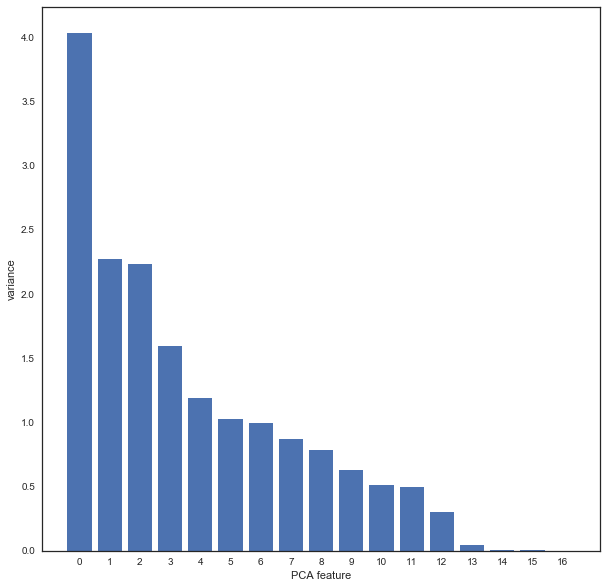

In [97]:
# Apply pca to reduce dimensions 

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler 
from sklearn.pipeline import make_pipeline 
import matplotlib.pyplot as plt 

# Create scaler 
scaler = StandardScaler()

# pca instance 
pca = PCA()

# Create pipeline
pipeline = make_pipeline(scaler, pca)

# fit pipeline 
pipeline.fit(cleaning4)

# Plot explained variances 
fig, ax = plt.subplots(figsize=(10,10))
features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_)
plt.xlabel('PCA feature')
plt.ylabel('variance')
plt.xticks(features)
plt.show()

In [158]:
cleaning4.isnull().any().sum()

0

In [159]:
cleaning4.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X13,X19,X21,X27,X28,X29,X30,X31,X32
1,0.1071,55742.0,114426.0,7000.0,7000.0,673.0,36.0,1,65000.0,112,14.29,7.0,0.0,33623.0,0.767,7.0,0
2,0.1699,57167.0,137225.0,25000.0,25000.0,24725.0,36.0,3,70000.0,100,10.50,10.0,0.0,19878.0,0.663,17.0,0
3,0.1311,57245.0,138150.0,1200.0,1200.0,1200.0,36.0,2,54000.0,777,5.47,5.0,0.0,2584.0,0.404,31.0,0
4,0.1357,57416.0,139635.0,10800.0,10800.0,10692.0,36.0,2,32000.0,67,11.63,14.0,0.0,3511.0,0.256,40.0,0
5,0.1905,58524.0,149512.0,7200.0,7200.0,7200.0,36.0,3,58000.0,28,2.05,6.0,0.0,3874.0,0.901,25.0,0


In [161]:
cleaning4.corr()

,X1,X2,X3,X4,X5,X6,X7,X13,X19,X21,X27,X28,X29,X30,X31,X32
X1,1.000000,0.031285,0.032728,0.182900,0.183862,0.186754,0.464185,-0.034627,-0.003276,0.156920,0.019457,0.077948,0.007434,0.344217,-0.025879,-0.011023
X2,0.031285,1.000000,0.994878,0.080949,0.085281,0.095452,0.080530,0.038949,-0.009400,0.117068,0.115989,0.127004,0.024256,-0.008382,0.095074,0.357165
X3,0.032728,0.994878,1.000000,0.084100,0.088570,0.099127,0.081608,0.039642,-0.008583,0.115502,0.114949,0.128661,0.024417,-0.007503,0.094018,0.359917
X4,0.182900,0.080949,0.084100,1.000000,0.998264,0.993463,0.410954,0.340471,-0.011010,0.062148,0.198262,-0.075644,0.338065,0.120875,0.235316,0.055373
X5,0.183862,0.085281,0.088570,0.998264,1.000000,0.995591,0.408713,0.339716,-0.010970,0.063609,0.199173,-0.075021,0.337650,0.122065,0.235167,0.057889
X6,0.186754,0.095452,0.099127,0.993463,0.995591,1.000000,0.409826,0.337697,-0.010483,0.068268,0.200297,-0.073136,0.335630,0.124661,0.235700,0.063903
X7,0.464185,0.080530,0.081608,0.410954,0.408713,0.409826,1.000000,0.061981,-0.034935,0.086162,0.067289,-0.014553,0.093156,0.086311,0.094069,0.040297
X13,-0.034627,0.038949,0.039642,0.340471,0.339716,0.337697,0.061981,1.000000,-0.013870,-0.178961,0.148133,-0.011824,0.302878,0.032449,0.218105,0.024857
X19,-0.003276,-0.009400,-0.008583,-0.011010,-0.010970,-0.010483,-0.034935,-0.013870,1.000000,0.011894,-0.050693,-0.003230,-0.023484,0.025322,-0.026008,0.001155
X21,0.156920,0.117068,0.115502,0.062148,0.063609,0.068268,0.086162,-0.178961,0.011894,1.000000,0.304237,-0.048380,0.150762,0.205693,0.228431,0.047608


In [187]:
data = cleaning4

y = data.iloc[:, 0] 

# Selected features for analysis 
cols = ['X7', 'X4', 'X5', 'X6', 'X21', 'X28', 'X30', 'X31' ]
X = data[cols]

In [206]:
# split X and y into training and testing sets
import sklearn.model_selection as cv
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) 

In [218]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score 

#  create linear regression object
regr = LinearRegression()

# train model  using testing set 
regr.fit(x, y)

# Make prediction with training set 
y_pred = regr.predict(X_test)

In [219]:
# The coefficients - overfit with a mean square error of 0
print('Coefficients: \n', regr.coef_)

# The mean squared error
print("Mean squared error: %.2f"
      % mean_squared_error(y_test, y_pred))

# Explained variance score: 1 is perfect prediction
print('Variance score: %.2f' % r2_score(y_test, y_pred))

Coefficients: 
 [  1.83388570e-03  -2.18259761e-06   1.56117776e-06   5.22308302e-07
   4.35962929e-04   9.63717725e-03   5.40473978e-02  -2.14803948e-04]
Mean squared error: 0.00
Variance score: 1.00


In [220]:
from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred))) 

Mean Absolute Error: 9.17847727395e-16
Mean Squared Error: 1.11947872294e-30
Root Mean Squared Error: 1.0580542155e-15


In [215]:
# Import DecisionTreeRegressor from sklearn.tree
from sklearn.tree import DecisionTreeRegressor
#(x_train, x_test, y_train, y_test) = cv.train_test_split(x, y, test_size=.20)
# Instantiate dt
dt = DecisionTreeRegressor(max_depth=40,
                           min_samples_leaf=0.25,
                           random_state=3)

# Fit dt to the training set
dt.fit(x_train, y_train)

DecisionTreeRegressor(criterion='mse', max_depth=40, max_features=None,
           max_leaf_nodes=None, min_impurity_decrease=0.0,
           min_impurity_split=None, min_samples_leaf=0.25,
           min_samples_split=2, min_weight_fraction_leaf=0.0,
           presort=False, random_state=3, splitter='best')

In [217]:
# Evaluate algorithm 

from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred))) 

Mean Absolute Error: 0.0201897242531
Mean Squared Error: 0.000624809199988
Root Mean Squared Error: 0.0249961837085


In [212]:
from sklearn.ensemble import RandomForestRegressor

# fit model 
regressor = RandomForestRegressor(n_estimators=8, random_state=0)  
regressor.fit(X_train, y_train)  

# make prediction
y_pred = regressor.predict(X_test)

In [213]:
y_pred

array([ 0.12153928,  0.1930061 ,  0.13128583, ...,  0.13203283,
        0.13919117,  0.19100911])

In [214]:
# Evaluate algorithm 

from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred))) 

Mean Absolute Error: 0.000513817918777
Mean Squared Error: 1.87418572747e-06
Root Mean Squared Error: 0.00136900903119


In [263]:
from sklearn import datasets, linear_model
from sklearn.model_selection import cross_validate
from sklearn.metrics.scorer import make_scorer
from sklearn.metrics import confusion_matrix
from sklearn.svm import LinearSVC

X = X
y = y 
lasso = linear_model.Lasso()

In [264]:
scores = cross_validate(lasso, X, y, cv=3, 
                        scoring=('r2', 'neg_mean_squared_error'),
                        return_train_score=True)
print(scores['test_neg_mean_squared_error'])  
print(scores['train_r2']) 

[-0.00053619 -0.00055829 -0.00060441]
[ 0.097793    0.1134057   0.10530632]


## Step 3:
Test your models using the data found within the "Holdout for Testing" file. Save the results of the final model (remember you will only predict the first column in holdout test set with your best model results) in a single, separate CSV titled "Results from" *insert your name or UChicago net ID.


In [221]:
#Select feature column names and target variable we are going to use for training
features = ['X7', 'X4', 'X5', 'X6', 'X21', 'X28', 'X30', 'X31' ]
target = 'X1'

In [223]:
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_estimators=8, random_state=0)  
regressor.fit(cleaning4[features], cleaning4[target])  


RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
           max_features='auto', max_leaf_nodes=None,
           min_impurity_decrease=0.0, min_impurity_split=None,
           min_samples_leaf=1, min_samples_split=2,
           min_weight_fraction_leaf=0.0, n_estimators=8, n_jobs=1,
           oob_score=False, random_state=0, verbose=0, warm_start=False)

In [255]:
predictions = regressor.predict(holdout2[features])


In [257]:
submission = pd.DataFrame({'Predicted Interest Rate': predictions})

In [1]:

filename = 

submission.to_csv(filename, index=False)

print('Saved file: ' + filename)

SyntaxError: invalid syntax (<ipython-input-1-8732d8e85bf3>, line 1)